## Decision tree regression
Decision tree regression is a machine learning technique used to predict continuous numerical values (such as house prices or temperature) using a hierarchical, tree-like structure. It operates by recursively splitting the dataset into smaller, more homogeneous subsets based on input features, a process also known as the CART (Classification and Regression Trees) algorithm. 

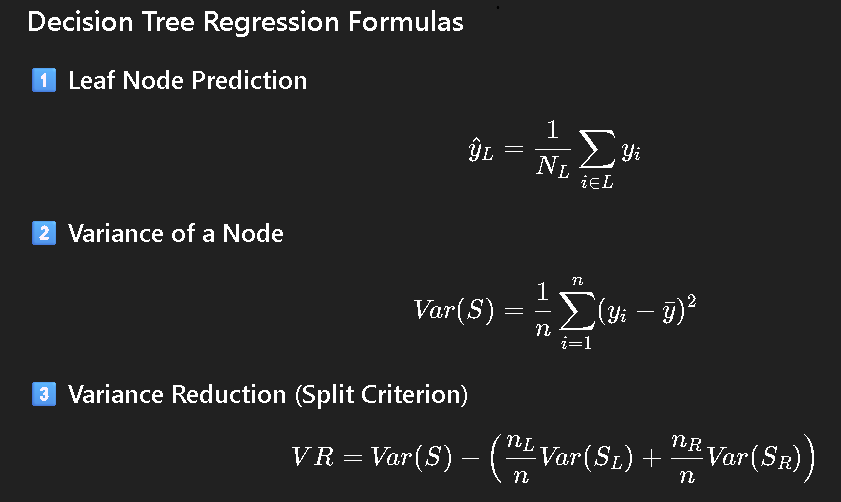
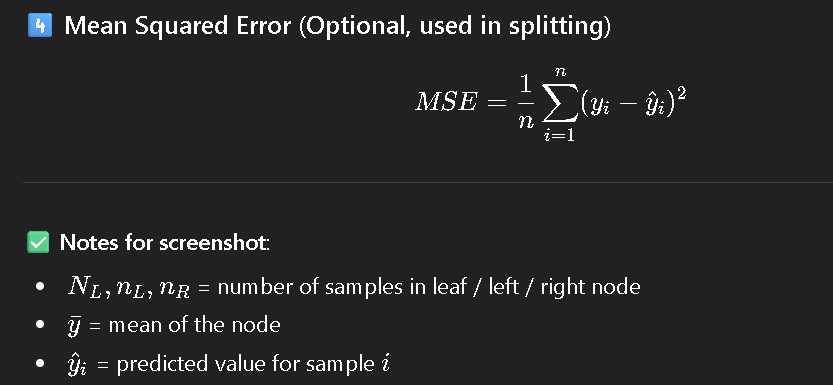

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [32]:
df=pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [48]:
xz=LabelEncoder()
df["ocean_proximity"]=xz.fit_transform(df["ocean_proximity"])
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [49]:
X=df.drop(columns=["median_house_value"])
y=df["ocean_proximity"]
# df["ocean_proximity"].value_counts()

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [51]:
model=DecisionTreeRegressor()

In [52]:
model.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [53]:
yy_pred=model.predict(X_test)
print("Accuracy_score: \n",accuracy_score(y_test, yy_pred))
print("Confusion_matrix: \n",confusion_matrix(y_test, yy_pred))

Accuracy_score: 
 1.0
Confusion_matrix: 
 [[1851    0    0    0    0]
 [   0 1290    0    0    0]
 [   0    0    2    0    0]
 [   0    0    0  442    0]
 [   0    0    0    0  543]]


In [54]:
y_pred=model.predict(X_train)
print("Accuracy_score: \n",accuracy_score(y_train, y_pred))
print("Confusion_matrix: \n",confusion_matrix(y_train, y_pred))

Accuracy_score: 
 1.0
Confusion_matrix: 
 [[7285    0    0    0    0]
 [   0 5261    0    0    0]
 [   0    0    3    0    0]
 [   0    0    0 1848    0]
 [   0    0    0    0 2115]]


In [55]:
model.predict([[-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0]])

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([4.])

[Text(0.5, 0.875, 'x[8] <= 1.5\nsquared_error = 2.014\nsamples = 16512\nvalue = 1.167'),
 Text(0.25, 0.625, 'x[8] <= 0.5\nsquared_error = 0.243\nsamples = 12546\nvalue = 0.419'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'squared_error = 0.0\nsamples = 7285\nvalue = 0.0'),
 Text(0.375, 0.375, 'squared_error = 0.0\nsamples = 5261\nvalue = 1.0'),
 Text(0.75, 0.625, 'x[8] <= 3.5\nsquared_error = 0.25\nsamples = 3966\nvalue = 3.533'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 35.39\nsquared_error = 0.002\nsamples = 1851\nvalue = 2.998'),
 Text(0.5, 0.125, 'squared_error = 0.0\nsamples = 3\nvalue = 2.0'),
 Text(0.75, 0.125, 'squared_error = 0.0\nsamples = 1848\nvalue = 3.0'),
 Text(0.875, 0.375, 'squared_error = 0.0\nsamples = 2115\nvalue = 4.0')]

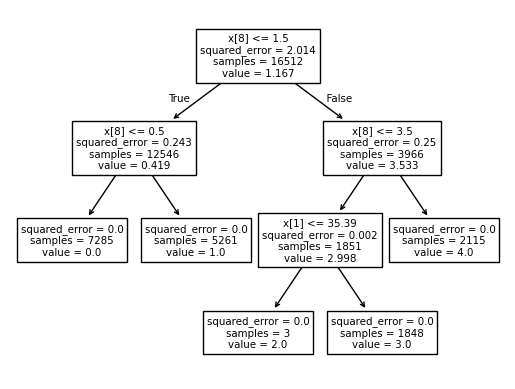

In [56]:
plot_tree(model)